# Data Preprocessing & Model Training Pipeline


In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# File path to the original raw dataset
DATA_PATH = r"data/AI purchase cost project (STUDENT DATA) V2 (1)(Blad2).csv"

# Let's load the data
df = pd.read_csv(DATA_PATH, sep=";", decimal=",")
print(f"Dataset Loaded Successfully! Shape: {df.shape}")
df.head()





Dataset Loaded Successfully! Shape: (780760, 11)


,Shipment,LAADDATUM,Load code,Unload code,Payweight,Distribution driven by code,Price category,Crossdock,ADR,Express,Thermo
0,2261706,1-1-2023,217,535,647.5,19,C,Y,N,N,N
1,2272552,2-1-2023,9,302,700.0,18,B,Y,N,N,N
2,2272495,2-1-2023,66,1855,21000.0,76,E,N,N,N,N
3,2272650,2-1-2023,181,608,700.0,18,B,Y,N,N,N
4,2273247,2-1-2023,21,1010,2100.0,77,C,Y,N,N,N


## Step 1: Preprocessing Pipeline
We must convert dates, manage our high-cardinality discrete location codes (via Frequency Encoding to respect memory footprints), boolean cast string columns, and Target Encode our `Price category` classifications.


In [2]:
def preprocess_data(df):
    print("Starting preprocessing...")
    df_clean = df.copy()

    # 1. Drop Shipments
    if 'Shipment' in df_clean.columns:
        df_clean = df_clean.drop('Shipment', axis=1)

    # 2. Date parsing (LAADDATUM)
    df_clean['LAADDATUM'] = pd.to_datetime(df_clean['LAADDATUM'], format='%d-%m-%Y', errors='coerce')
    df_clean['Load_Year'] = df_clean['LAADDATUM'].dt.year
    df_clean['Load_Month'] = df_clean['LAADDATUM'].dt.month
    df_clean['Load_DayOfWeek'] = df_clean['LAADDATUM'].dt.dayofweek
    df_clean['Load_Day'] = df_clean['LAADDATUM'].dt.day
    df_clean = df_clean.drop('LAADDATUM', axis=1)

    # 3. Y/N -> 1/0
    bool_cols = ['Crossdock', 'ADR', 'Express', 'Thermo']
    for col in bool_cols:
        df_clean[col] = df_clean[col].map({'Y': 1, 'N': 0}).fillna(0).astype('int8')

    # 4. Handle High-Cardinality Variables (Frequency Encoding)
    high_card_cols = ['Load code', 'Unload code', 'Distribution driven by code']
    for col in high_card_cols:
        freq_encoding = df_clean[col].value_counts() / len(df_clean)
        df_clean[col + '_freq'] = df_clean[col].map(freq_encoding)
        df_clean = df_clean.drop(col, axis=1)

    return df_clean

df_processed = preprocess_data(df)
print(f"Data preprocessed! New Shape: {df_processed.shape}")
df_processed.head()


Starting preprocessing...
Data preprocessed! New Shape: (780760, 13)


,Payweight,Price category,Crossdock,ADR,Express,Thermo,Load_Year,Load_Month,Load_DayOfWeek,Load_Day,Load code_freq,Unload code_freq,Distribution driven by code_freq
0,647.5,C,1,0,0,0,2023,1,6,1,0.000004,0.006960,0.011648
1,700.0,B,1,0,0,0,2023,1,0,2,0.121087,0.001045,0.007516
2,21000.0,E,0,0,0,0,2023,1,0,2,0.022665,0.000088,0.000661
3,700.0,B,1,0,0,0,2023,1,0,2,0.003854,0.000220,0.007516
4,2100.0,C,1,0,0,0,2023,1,0,2,0.013203,0.000184,0.000211


## Step 2: Target Variable and Train-Test Split
Let's properly map and organize the target (`Price category`), then slice it into our Training and Testing sets.


In [3]:
# Encode target
le = LabelEncoder()
df_processed['Price category encoded'] = le.fit_transform(df_processed['Price category'].astype(str))

# Create mapping dictionary for future reference
price_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Category Mapping (first 5 shown): {list(price_mapping.items())[:5]}")

# Define Features (X) and Target (y)
y = df_processed['Price category encoded']
X = df_processed.drop(['Price category', 'Price category encoded'], axis=1)

# Split data (80% Train, 20% validation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")


Category Mapping (first 5 shown): [('B', np.int64(0)), ('C', np.int64(1)), ('D', np.int64(2)), ('E', np.int64(3)), ('F', np.int64(4))]
Training features shape: (624608, 12)
Testing features shape: (156152, 12)


## Step 2.5: Exploratory Data Analysis Before Modeling

This section adds a compact exploratory analysis before training any model.

- The summary tables describe the structure and quality of the raw dataset.
- The price-category chart shows whether the target is balanced or dominated by a few categories.
- The feature heatmap shows how the processed input features relate to one another.
- The payweight chart checks whether one of the main numeric inputs changes visibly across price categories.

These checks are useful because they help explain model behaviour before any training starts.

In [ ]:
from IPython.display import display
import matplotlib.pyplot as plt

# High-level dataset summary for documentation before modelling.
load_dates = pd.to_datetime(df['LAADDATUM'], format='%d-%m-%Y', errors='coerce')

dataset_overview = pd.DataFrame({
    'Metric': [
        'Rows',
        'Columns',
        'Date range start',
        'Date range end',
        'Missing cells',
        'Duplicate rows',
        'Unique price categories',
    ],
    'Value': [
        len(df),
        df.shape[1],
        load_dates.min().date(),
        load_dates.max().date(),
        int(df.isna().sum().sum()),
        int(df.duplicated().sum()),
        df['Price category'].nunique(),
    ]
})

feature_profile = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.astype(str).values,
    'Missing Values': df.isna().sum().values,
    'Missing %': (df.isna().mean() * 100).round(2).values,
    'Unique Values': df.nunique().values,
})

print('Dataset overview:')
display(dataset_overview)

print('Feature profile:')
display(feature_profile.sort_values(['Missing Values', 'Unique Values'], ascending=[False, False]).reset_index(drop=True))

### Price Category Frequency

This bar chart shows how often each target class appears in the full dataset.

- It is mainly a target-balance check.
- If a few classes dominate, accuracy can look strong even when minority classes are predicted poorly.
- This is important context for choosing evaluation metrics later, especially because the train/test split is stratified by class.

In [ ]:
price_counts = df['Price category'].value_counts().sort_values(ascending=False)
price_percent = price_counts / price_counts.sum()

price_distribution = pd.DataFrame({
    'Count': price_counts,
    'Share %': (price_percent * 100).round(2),
})

display(price_distribution)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(price_counts.index.astype(str), price_counts.values, color='steelblue', edgecolor='black', linewidth=0.4)
ax.set_title('Price Category Distribution Across the Full Dataset')
ax.set_xlabel('Price Category')
ax.set_ylabel('Number of Shipments')
ax.grid(axis='y', linestyle='--', alpha=0.35)

for bar, pct in zip(bars, price_percent.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{pct:.1%}',
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=90
    )

plt.tight_layout()
plt.show()

### Feature Correlation Heatmap

This heatmap shows the pairwise correlations between the processed model features.

- Positive values mean two features tend to increase together.
- Negative values mean one tends to rise when the other falls.
- Values close to zero suggest little linear relationship.

This is useful before modelling because very strong relationships can indicate overlapping information, while isolated features may contribute unique signal.

In [ ]:
corr_matrix = X.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
heatmap = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index)
ax.set_title('Correlation Heatmap of Processed Features')

cbar = plt.colorbar(heatmap, ax=ax)
cbar.set_label('Correlation')

plt.tight_layout()
plt.show()

high_corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
high_corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
high_corr_pairs['Absolute Correlation'] = high_corr_pairs['Correlation'].abs()
high_corr_pairs = high_corr_pairs.sort_values('Absolute Correlation', ascending=False)

print('Strongest feature relationships:')
display(high_corr_pairs.head(10).round(3))

### Payweight Distribution by Major Price Categories

This boxplot compares the shipment `Payweight` distribution across the most common price categories.

- The line inside each box is the median.
- The box shows the middle 50% of values.
- The chart uses a log scale so the wide weight range remains readable.

This is useful because it checks whether payweight separates categories in a visible way, which helps judge how much predictive value it may carry before training.

In [ ]:
top_categories = price_counts.head(8).index
payweight_subset = df[df['Price category'].isin(top_categories)].copy()
payweight_data = [
    payweight_subset.loc[payweight_subset['Price category'] == category, 'Payweight']
    for category in top_categories
]

fig, ax = plt.subplots(figsize=(12, 6))
box = ax.boxplot(payweight_data, tick_labels=top_categories, patch_artist=True, showfliers=False)

for patch in box['boxes']:
    patch.set(facecolor='lightsteelblue', alpha=0.85)

ax.set_yscale('log')
ax.set_title('Payweight Distribution for the 8 Most Common Price Categories')
ax.set_xlabel('Price Category')
ax.set_ylabel('Payweight (log scale)')
ax.grid(axis='y', linestyle='--', alpha=0.35)

plt.tight_layout()
plt.show()

payweight_summary = (
    payweight_subset.groupby('Price category')['Payweight']
    .agg(['count', 'median', 'mean', 'min', 'max'])
    .round(2)
    .loc[top_categories]
)

print('Payweight summary by major price category:')
display(payweight_summary)

## Feature Influence Checkpoint
Before training the model, this section measures how informative each feature is for predicting the target. It adds a ranked table, a visualization of the strongest signals, and compact summary tables to show how the most influential features vary across price categories.


Feature influence ranking (all features):


,Influence Rank,Feature,Mutual Information
0,1,Payweight,0.5740
1,2,Load code_freq,0.2430
2,3,Crossdock,0.1202
3,4,Unload code_freq,0.0529
4,5,Express,0.0151
5,6,Load_Year,0.0148
6,7,Load_DayOfWeek,0.0088
7,8,Load_Month,0.0049
8,9,Thermo,0.0047
9,10,ADR,0.0027


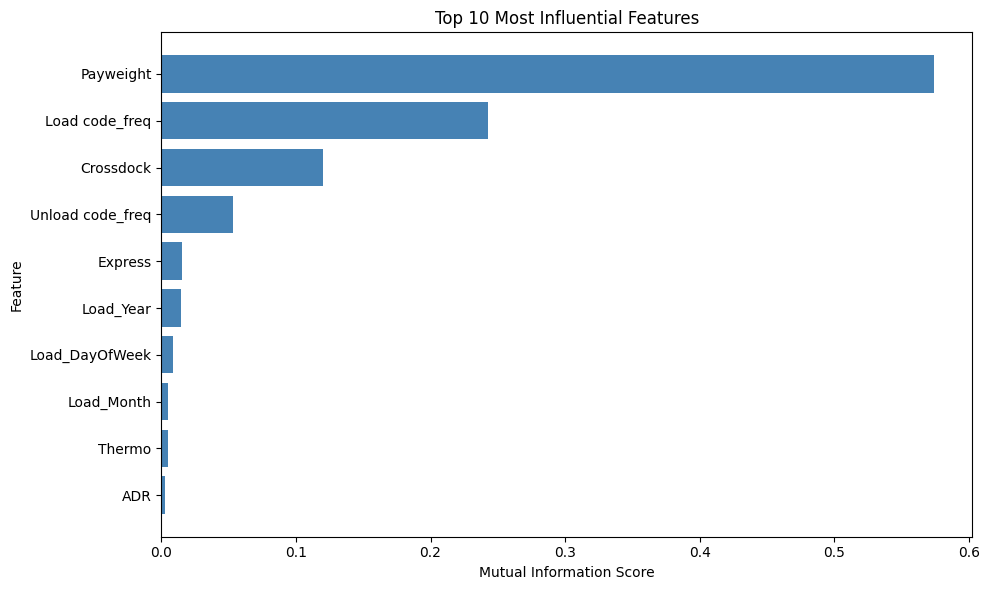

How the top features vary across price categories:


Payweight           Load code_freq        Crossdock         \
                     mean    median           mean median      mean median   
Price category                                                               
B                1000.798    700.00          0.049  0.030     0.630    1.0   
C                2040.361   1347.50          0.031  0.014     0.793    1.0   
D                6181.030   2625.00          0.029  0.014     0.585    1.0   
E                8319.294   4200.00          0.027  0.014     0.481    0.0   
F                8217.772   5250.00          0.027  0.013     0.432    0.0   
G               10020.730   7000.00          0.024  0.010     0.320    0.0   
H               14635.151  13000.00          0.027  0.014     0.190    0.0   
I               18189.181  21700.00          0.024  0.017     0.126    0.0   
J               20530.143  23100.00          0.023  0.014     0.063    0.0   
K               20350.270  23100.00          0.027  0.023     0.085    0.0   
L               19094.696  21875.00          0.041  0.023     0.111    0.0   
M               21615.916  23800.00          0.027  0.023     0.098    0.0   
N               20997.608  23800.00          0.038  0.035     0.056    0.0   
O               20068.255  22200.00          0.042  0.030     0.093    0.0   
P               20296.174  21411.25          0.061  0.035     0.151    0.0   
Q               22450.575  21682.50          0.081  0.121     0.014    0.0   
R               22331.470  22000.00          0.050  0.035     0.010    0.0   
S               22200.049  22000.00          0.027  0.000     0.000    0.0   
T               21311.399  21000.00          0.023  0.029     0.000    0.0   
U               21477.410  21000.00          0.025  0.029     0.000    0.0   
V               22015.123  21000.00          0.026  0.035     0.033    0.0   

               Unload code_freq        Express         
                           mean median    mean median  
Price category                                         
B                         0.002  0.001   0.000    0.0  
C                         0.001  0.001   0.001    0.0  
D                         0.001  0.001   0.007    0.0  
E                         0.001  0.001   0.009    0.0  
F                         0.001  0.000   0.035    0.0  
G                         0.001  0.000   0.081    0.0  
H                         0.001  0.000   0.038    0.0  
I                         0.001  0.000   0.041    0.0  
J                         0.001  0.000   0.047    0.0  
K                         0.001  0.000   0.057    0.0  
L                         0.001  0.000   0.167    0.0  
M                         0.001  0.000   0.066    0.0  
N                         0.000  0.000   0.060    0.0  
O                         0.000  0.000   0.091    0.0  
P                         0.001  0.000   0.074    0.0  
Q                         0.001  0.000   0.029    0.0  
R                         0.001  0.000   0.040    0.0  
S                         0.001  0.001   0.009    0.0  
T                         0.002  0.001   0.038    0.0  
U                         0.002  0.001   0.000    0.0  
V                         0.002  0.001   0.082    0.0

In [4]:
from IPython.display import display
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

# Estimate how much information each feature provides about the target.
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)

feature_influence = (
    pd.DataFrame({
        'Feature': X_train.columns,
        'Mutual Information': mi_scores
    })
    .sort_values('Mutual Information', ascending=False)
    .reset_index(drop=True)
)
feature_influence['Influence Rank'] = feature_influence.index + 1
feature_influence = feature_influence[['Influence Rank', 'Feature', 'Mutual Information']]

print('Feature influence ranking (all features):')
display(feature_influence.style.format({'Mutual Information': '{:.4f}'}))

top_n = min(10, len(feature_influence))
top_features = feature_influence.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'][::-1], top_features['Mutual Information'][::-1], color='steelblue')
plt.xlabel('Mutual Information Score')
plt.ylabel('Feature')
plt.title(f'Top {top_n} Most Influential Features')
plt.tight_layout()
plt.show()

# Show how the strongest features differ across target classes.
summary_features = feature_influence.head(min(5, len(feature_influence)))['Feature'].tolist()
feature_summary_by_category = (
    df_processed.groupby('Price category')[summary_features]
    .agg(['mean', 'median'])
    .round(3)
)

print('How the top features vary across price categories:')
display(feature_summary_by_category)


## Step 3: Setting Up Models (Trainer 1)
Here is where we will proceed with the first of our 3 Machine Learning models! A great baseline classifier for this task is a **Random Forest Classifier**.


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the first model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# TODO: Fit the model using rf_model.fit(X_train, y_train) 
# Note: This dataframe is extremely large (~600k rows) so training might take a minute!
